# Âge de l'appareil vs profil de pannes

## Objectif de ce notebook

Est-ce que certains chapitres ATA sont davantage signalés sur des avions **jeunes** (défauts de jeunesse) que sur des avions **âgés** (usure/fatigue mécanique) — ou l'inverse ?

On utilise `AircraftTotalCycles` (1 cycle = 1 décollage + 1 atterrissage) comme indicateur d'âge — plus pertinent que les heures de vol pour l'usure mécanique, qui est surtout liée au nombre de fois où la structure est sollicitée (pressurisation, atterrissage), pas juste au temps passé en l'air.

In [1]:
import sys
sys.path.append("../src")

import matplotlib.pyplot as plt
import pandas as pd

from sdr_analytics import config
from sdr_analytics.metrics import pareto_table

df = pd.read_parquet(config.CHEMIN_DONNEES_TRAITEES / "sdr_airbus_clean.parquet")
df_perimetre = df[df["dans_perimetre"] & df["annee_complete"]].copy()
print(f"{len(df_perimetre)} lignes dans le périmètre")

112195 lignes dans le périmètre


## 1. Combien de lignes ont un nombre de cycles connu ?

Rappel du notebook 02 : quelques valeurs de cycles manifestement fausses ont été neutralisées (mises à vide). On ne peut classer par âge que les lignes où cette information est disponible.

In [2]:
avant = len(df_perimetre)
df_age = df_perimetre[df_perimetre["AircraftTotalCycles"].notna()].copy()
print(f"Lignes avec un nombre de cycles connu : {len(df_age)} sur {avant} ({len(df_age) / avant * 100:.1f}%)")

Lignes avec un nombre de cycles connu : 110998 sur 112195 (98.9%)


## 2. Découper en tranches d'âge — par famille, pas globalement

**Point méthodologique important** : on ne peut pas utiliser les mêmes seuils de cycles pour toutes les familles. L'A350 est un avion long-courrier : il vole moins souvent (moins de décollages/atterrissages) mais plus longtemps à chaque vol, donc il accumule des cycles beaucoup plus lentement qu'un A320 qui fait des vols courts et fréquents. Si on utilisait un seuil unique, on classerait presque tous les A350 comme "jeunes" — non pas parce qu'ils le sont vraiment, mais juste à cause du type d'avion.

La solution : découper chaque famille **séparément** en 3 groupes de taille égale (jeune / mature / âgé), chacun par rapport aux autres avions de sa propre famille.

In [3]:
def tercile_par_groupe(cycles):
    return pd.qcut(cycles, 3, labels=["jeune", "mature", "âgé"], duplicates="drop")

df_age["tranche_age"] = df_age.groupby("famille_appareil")["AircraftTotalCycles"].transform(tercile_par_groupe)

# Affichage des seuils retenus pour chaque famille, pour que ce soit vérifiable
for famille, groupe in df_age.groupby("famille_appareil"):
    _, seuils = pd.qcut(groupe["AircraftTotalCycles"], 3, retbins=True, duplicates="drop")
    seuils_lisibles = ", ".join(f"{s:,.0f}" for s in seuils)
    print(f"{famille} : seuils de cycles = [{seuils_lisibles}]")

print()
df_age["tranche_age"].value_counts()

A320 : seuils de cycles = [1, 14,244, 28,259, 103,410]
A330 : seuils de cycles = [4, 4,321, 9,355, 87,097]
A350 : seuils de cycles = [4, 1,365, 2,389, 4,323]



tranche_age
mature    37055
jeune     37002
âgé       36941
Name: count, dtype: int64

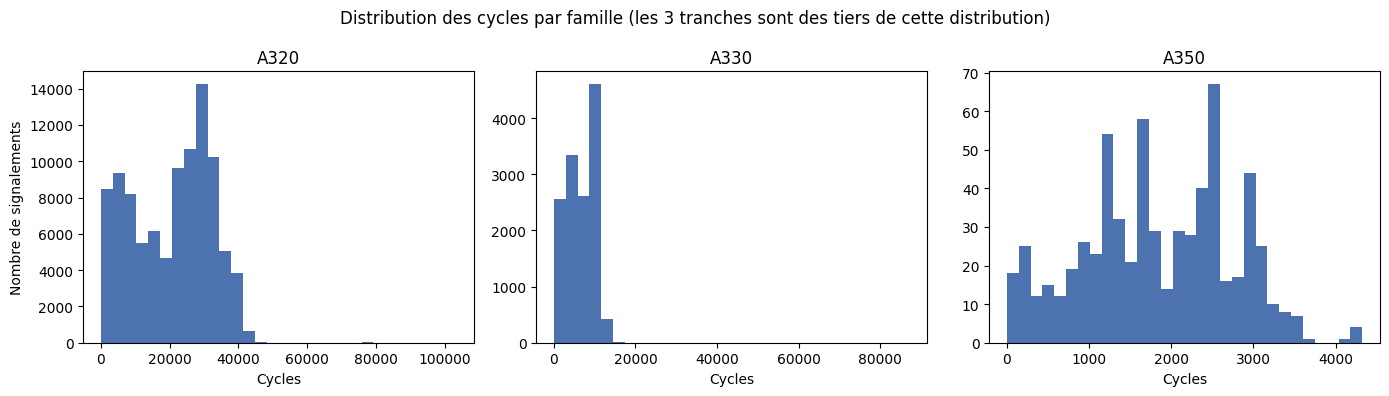

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=False)

for ax, (famille, groupe) in zip(axes, df_age.groupby("famille_appareil")):
    ax.hist(groupe["AircraftTotalCycles"], bins=30, color="#4C72B0")
    ax.set_title(famille)
    ax.set_xlabel("Cycles")

axes[0].set_ylabel("Nombre de signalements")
fig.suptitle("Distribution des cycles par famille (les 3 tranches sont des tiers de cette distribution)")
fig.tight_layout()
plt.show()

## 3. Quels chapitres sont sur-représentés selon la tranche d'âge ?

Pour chaque combinaison (chapitre, tranche d'âge), on compare le nombre de signalements **observé** à ce qu'on **attendrait** s'il n'y avait aucun lien entre chapitre et âge (c'est-à-dire si chaque tranche recevait simplement sa part proportionnelle de chaque chapitre). Le rapport observé/attendu — le **lift** — se lit simplement :

- lift = 1 : ni plus ni moins signalé que la moyenne pour cette tranche d'âge
- lift = 1.4 : signalé 40% de plus que ce à quoi on s'attendrait
- lift = 0.6 : signalé 40% de moins que ce à quoi on s'attendrait

On se limite aux 10 chapitres les plus signalés (notebook 03), pour rester lisible.

In [5]:
top10_chapitres = pareto_table(df_age.groupby("chapitre_ata").size()).head(10).index.tolist()
libelles = df_age[["chapitre_ata", "libelle_ata"]].drop_duplicates().set_index("chapitre_ata")["libelle_ata"]

sous_ensemble = df_age[df_age["chapitre_ata"].isin(top10_chapitres)]

comptage = sous_ensemble.groupby(["chapitre_ata", "tranche_age"], observed=True).size().rename("observe").reset_index()
total_par_chapitre = sous_ensemble.groupby("chapitre_ata").size().rename("total_chapitre")
total_par_tranche = sous_ensemble.groupby("tranche_age", observed=True).size().rename("total_tranche")
total_general = len(sous_ensemble)

comptage = comptage.merge(total_par_chapitre, on="chapitre_ata").merge(total_par_tranche, on="tranche_age")
comptage["attendu"] = comptage["total_chapitre"] * comptage["total_tranche"] / total_general
comptage["lift"] = comptage["observe"] / comptage["attendu"]

tableau_lift = comptage.pivot(index="chapitre_ata", columns="tranche_age", values="lift")
tableau_lift = tableau_lift.reindex(top10_chapitres)[["jeune", "mature", "âgé"]]
tableau_lift.index = tableau_lift.index.map(libelles)

tableau_lift.round(2)

tranche_age,jeune,mature,âgé
chapitre_ata,,,
Fuselage,0.49,1.19,1.31
Éclairage,1.20,1.02,0.79
Portes,1.53,0.69,0.80
Équipements et aménagements,1.55,0.79,0.68
Climatisation,1.67,0.95,0.40
Empennages,0.78,1.05,1.16
Voilure (ailes),0.25,0.94,1.78
Train d'atterrissage,0.85,1.11,1.03
Groupe auxiliaire de puissance (APU),1.18,1.10,0.73


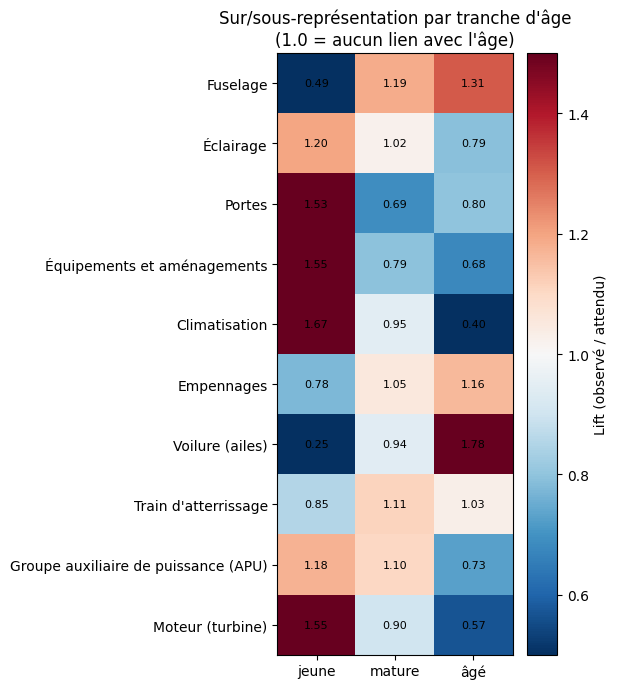

In [6]:
import numpy as np

fig, ax = plt.subplots(figsize=(6, 7))
im = ax.imshow(tableau_lift.values, cmap="RdBu_r", vmin=0.5, vmax=1.5, aspect="auto")

ax.set_xticks(range(len(tableau_lift.columns)))
ax.set_xticklabels(tableau_lift.columns)
ax.set_yticks(range(len(tableau_lift.index)))
ax.set_yticklabels(tableau_lift.index)

for i in range(tableau_lift.shape[0]):
    for j in range(tableau_lift.shape[1]):
        ax.text(j, i, f"{tableau_lift.values[i, j]:.2f}", ha="center", va="center", fontsize=8)

plt.colorbar(im, ax=ax, label="Lift (observé / attendu)")
plt.title("Sur/sous-représentation par tranche d'âge\n(1.0 = aucun lien avec l'âge)")
plt.tight_layout()
plt.show()

## Ce qu'on retient

Deux profils bien distincts se dégagent nettement du tableau de lift :

- **Défauts d'usure/fatigue (le lift augmente avec l'âge)** : le **Fuselage** (0.49 → 1.19 → 1.31) et surtout la **Voilure** (0.25 → 0.94 → 1.78) sont nettement sous-représentés sur les avions jeunes et sur-représentés sur les avions âgés. C'est exactement le profil attendu pour des éléments structurels soumis à la fatigue mécanique (pressurisation répétée, contraintes de vol) — plus l'avion cumule de cycles, plus ce type de défaut apparaît.
- **Défauts de jeunesse (le lift diminue avec l'âge)** : à l'inverse, la **Climatisation** (1.67 → 0.95 → 0.40), le **Moteur** (1.55 → 0.90 → 0.57), les **Équipements/aménagements** (1.55 → 0.79 → 0.68) et les **Portes** (1.53 → 0.69 → 0.80) sont nettement sur-représentés sur les avions jeunes. Cohérent avec des systèmes/équipements qui posent davantage de problèmes au début de leur mise en service (réglages, rodage) et qui se stabilisent ensuite.

**Implication opérationnelle directe** (le genre de conclusion qui parle à une équipe maintenance) : ces deux profils suggèrent des priorités d'inspection différentes selon l'âge de la flotte — surveillance structurelle renforcée sur les avions âgés (fuselage, voilure), vigilance sur les systèmes/équipements en début de vie plutôt qu'en fin de vie.

**Limite méthodologique à rappeler** : le "lift" indique une association, pas une preuve de cause. Et les tranches d'âge sont définies par famille (des seuils de cycles très différents entre A320 et A350, cf. §2) — donc "âgé" ne veut pas dire le même nombre de cycles absolu selon la famille.

*(Ces points seront repris dans `docs/methodologie_limites.md`.)*